# WhatsApp Chat Analysis Project
This notebook demonstrates how to process, analyze, and visualize WhatsApp chat data using Python. Each code cell is explained with professional markdown comments for clarity.

In [17]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer #Natural Language Toolkit's VADER module for sentiment analysis

## Import Required Libraries
Import pandas for data manipulation and analysis.

In [18]:
df = pd.read_csv("mabel.txt", header=None, encoding='utf8', on_bad_lines='skip')

## Load Chat Data
Read the WhatsApp chat data from a text file into a pandas DataFrame. Handle encoding and bad lines for robust loading.

In [19]:
df=df.drop(0)
df.columns=['Date','Chat']
Message=df["Chat"].str.split("-",n=1,expand=True)
df["Time"]=Message[0]
Message1=Message[1].str.split(":",n=1,expand=True)
df["Name"]=Message1[0]
df["Chat"]=Message1[1]
df=df[["Date","Time","Name","Chat"]]
df

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?
7,05/12/19,1:43 pm,AR❤,Yes Mam
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working
9,05/12/19,1:43 pm,AR❤,Yeah mam
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too


## Data Cleaning and Preprocessing
Remove unnecessary rows, set column names, and split chat messages into time, name, and message content for structured analysis.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 1 to 50
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    50 non-null     object
 1   Time    50 non-null     object
 2   Name    50 non-null     object
 3   Chat    50 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB


## Data Overview
Display information about the DataFrame to understand the structure and data types.

## Import Sentiment Analysis Tool
Import VADER sentiment analyzer from NLTK for sentiment analysis of chat messages.

In [21]:
dataset=df

## Prepare Dataset for Analysis
Assign the cleaned DataFrame to a new variable for further analysis.

In [22]:
dataset.dropna(inplace=True)
nltk.download('vader_lexicon') # Download VADER lexicon for sentiment analysisß
print(dataset)

        Date        Time              Name  \
1   05/12/19    1:42 pm    Mabel Infoziant   
2   05/12/19    1:42 pm    Mabel Infoziant   
3   05/12/19    1:42 pm                AR❤   
4   05/12/19    1:42 pm    Mabel Infoziant   
5   05/12/19    1:42 pm    Mabel Infoziant   
6   05/12/19    1:43 pm    Mabel Infoziant   
7   05/12/19    1:43 pm                AR❤   
8   05/12/19    1:43 pm    Mabel Infoziant   
9   05/12/19    1:43 pm                AR❤   
10  05/12/19    1:43 pm    Mabel Infoziant   
11  05/12/19    1:43 pm    Mabel Infoziant   
12  05/12/19    1:44 pm                AR❤   
13  05/12/19    1:45 pm                AR❤   
14  05/12/19    1:48 pm    Mabel Infoziant   
15  05/12/19    1:48 pm    Mabel Infoziant   
16  05/12/19    1:49 pm                AR❤   
17  05/12/19    2:00 pm                AR❤   
18  05/12/19    2:04 pm    Mabel Infoziant   
19  05/12/19    2:04 pm    Mabel Infoziant   
20  05/12/19    2:06 pm                AR❤   
21  05/12/19    2:07 pm           

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/madhusudhananjeyaram/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Handle Missing Values
Remove any rows with missing values to ensure data quality for analysis.

In [23]:
sid = SentimentIntensityAnalyzer()

## Initialize Sentiment Analyzer
Create an instance of the VADER sentiment analyzer for scoring chat messages.

In [24]:
senti=sid.polarity_scores(dataset['Chat'][4])

print("1. Install NLTK and download the VADER lexicon.")
print("2. Import SentimentIntensityAnalyzer from nltk.sentiment.vader.")
print("3. Initialize the analyzer with sid = SentimentIntensityAnalyzer().")
print("4. Pass your text to sid.polarity_scores(text) to get sentiment scores.")
print("5. Use the returned dictionary (neg, neu, pos, compound) to interpret sentiment.")

1. Install NLTK and download the VADER lexicon.
2. Import SentimentIntensityAnalyzer from nltk.sentiment.vader.
3. Initialize the analyzer with sid = SentimentIntensityAnalyzer().
4. Pass your text to sid.polarity_scores(text) to get sentiment scores.
5. Use the returned dictionary (neg, neu, pos, compound) to interpret sentiment.


## Analyze Sentiment of a Message
Calculate sentiment scores for a specific chat message using VADER.

In [25]:
senti

{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.296}

## Display Sentiment Scores
Show the sentiment scores for the selected chat message.

In [26]:
 def sentimentalAnalysis(data,columnname):
        
        #downloading vader_lexicon for the process
        import matplotlib.pyplot as plt
        import seaborn as sns
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data['compound']  = data['scores'].apply(lambda score_dict: score_dict['compound'])
        data['Negtive']  = data['scores'].apply(lambda score_dict: score_dict['neg'])
        data['Postive']  = data['scores'].apply(lambda score_dict: score_dict['pos'])
        data['Neutral']  = data['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
        plt.clf()
        #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data['comp_score'].value_counts())
        return posneg,data
    

## Define Sentiment Analysis Function
Create a function to perform sentiment analysis on all chat messages, add sentiment columns, and visualize results.

In [27]:
pos,data_Senti=sentimentalAnalysis(dataset,columnname='Chat')

<Figure size 640x480 with 0 Axes>

## Run Sentiment Analysis
Apply the sentiment analysis function to the dataset and obtain positive/negative counts.

In [28]:
data_Senti

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos


## Display Sentiment Analysis Results
Show the dataset with added sentiment columns for each chat message.

In [29]:
pos

,count
comp_score,
pos,48
neg,2


## Display Positive/Negative Sentiment Counts
Show the count of positive and negative messages in the chat.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [32]:
from sklearn.decomposition import NMF
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)


,n_components,5
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [33]:
for index,topic in enumerate(nmf_model.components_):
    results = [tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
    print(results)

['share', 'soon', 'ask', 'yes', 'sure', 'read', 'abstract', 'kk', 'yeah', 'mam']
['hi', 'kk', 'know', 'meeting', 'yes', 'just', 'send', 'tomorrow', 'mam', 'ok']
['details', 'abstracts', 'start', 'students', 'phone', 'ask', 'office', 'number', 'vignesh', 'send']
['ask', 'abstracts', 'number', 'mam', 'office', 'know', 'just', 'tomorrow', 'church', 'hi']
['students', 'know', 'sure', 'share', 'soon', 'meeting', 'details', 'yes', 'need', 'ramisha']


In [34]:
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)


In [35]:
df

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,3
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,4
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos,1
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos,4
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos,0
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0


In [36]:
df["Topic"].value_counts()

Topic
0    22
2    12
4     6
3     5
1     5
Name: count, dtype: int64

In [37]:
#!pip install wordCloud

In [38]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/madhusudhananjeyaram/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

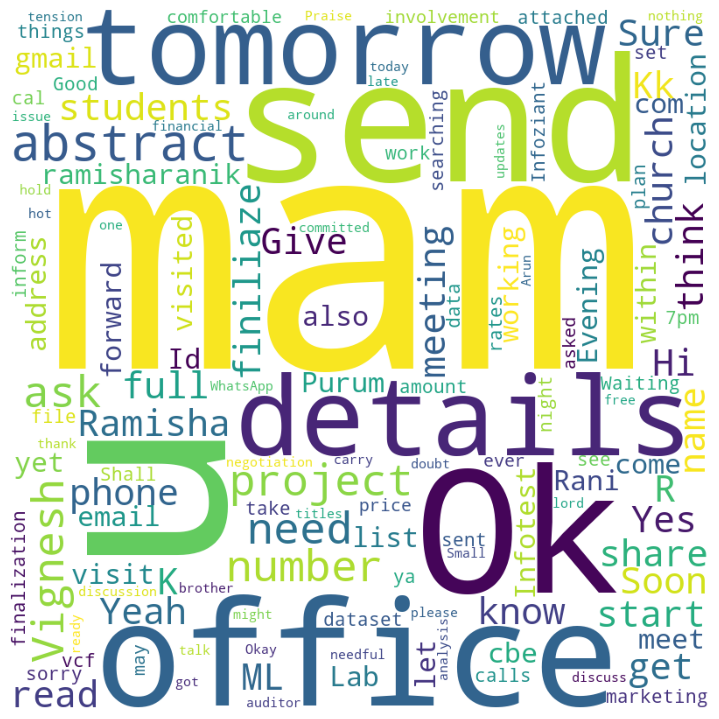

Successfully created


In [39]:

comment_words = []
stoplist = stopwords.words('english')
stoplist.extend(['omitted', 'voice','missed','call','video','deleted','media','message'])
wordcloudss="This function saves image"
dataset.index=range(dataset.shape[0])
for i in range(1,len(dataset)): 
    comment_words.append(dataset['Chat'][i])
    vv=" ".join(comment_words)          
    wordcloud = WordCloud(width = 800, height = 800, 
                                background_color ='white', 
                                      stopwords = stoplist, 
                                      min_font_size = 10).generate(vv)         
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.savefig('wordcloud.PNG')
plt.show() 
print("Successfully created")
wordcloudss="This function saves image"
